# Soal 1

Warna yang sama dapat tampak berbeda pada kondisi pencahayaan yang berbeda. `indoor.png` dan
`outdoor.png` adalah objek yang sama di bawah iluminasi yang berbeda.

**a.** Baca kedua citra dan plot channel R, G, B secara terpisah sebagai citra skala abu-abu dengan Matplotlib.

**b.** Konversi kedua citra ke ruang warna LAB dan plot ketiga channel-nya.

**c.** Bagaimana kita tahu bahwa perubahan pencahayaan terpisah lebih baik di ruang warna LAB? Jelaskan.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## a. Baca citra dan plot channel R, G, B sebagai citra skala abu-abu

indoor.png : (256, 256, 3)
outdoor.png: (256, 256, 3)


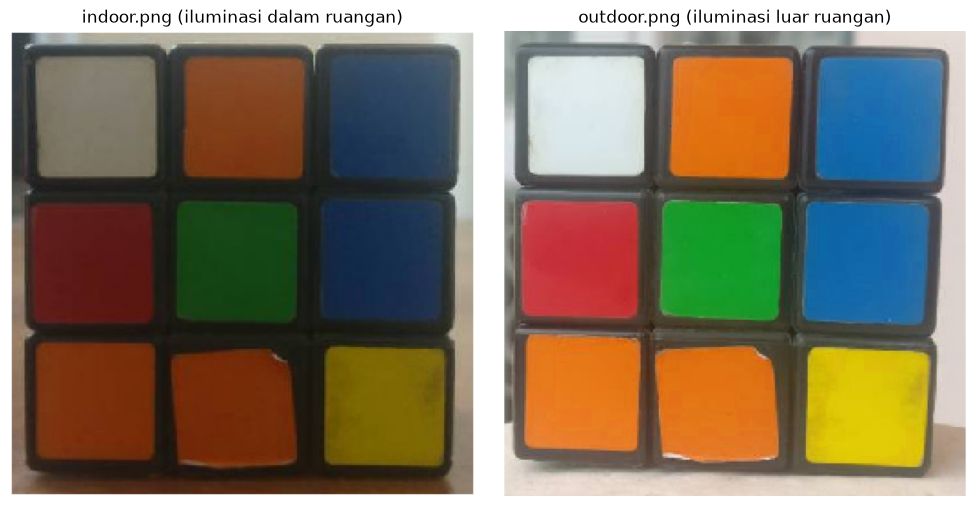

In [2]:
# Baca kedua citra (OpenCV membaca dalam urutan BGR)
indoor_bgr = cv2.imread('assets/indoor.png')
outdoor_bgr = cv2.imread('assets/outdoor.png')

# Konversi ke RGB agar warnanya benar saat ditampilkan dengan Matplotlib
indoor = cv2.cvtColor(indoor_bgr, cv2.COLOR_BGR2RGB)
outdoor = cv2.cvtColor(outdoor_bgr, cv2.COLOR_BGR2RGB)

print(f'indoor.png : {indoor.shape}')
print(f'outdoor.png: {outdoor.shape}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(indoor)
axes[0].set_title('indoor.png (iluminasi dalam ruangan)')
axes[0].axis('off')
axes[1].imshow(outdoor)
axes[1].set_title('outdoor.png (iluminasi luar ruangan)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

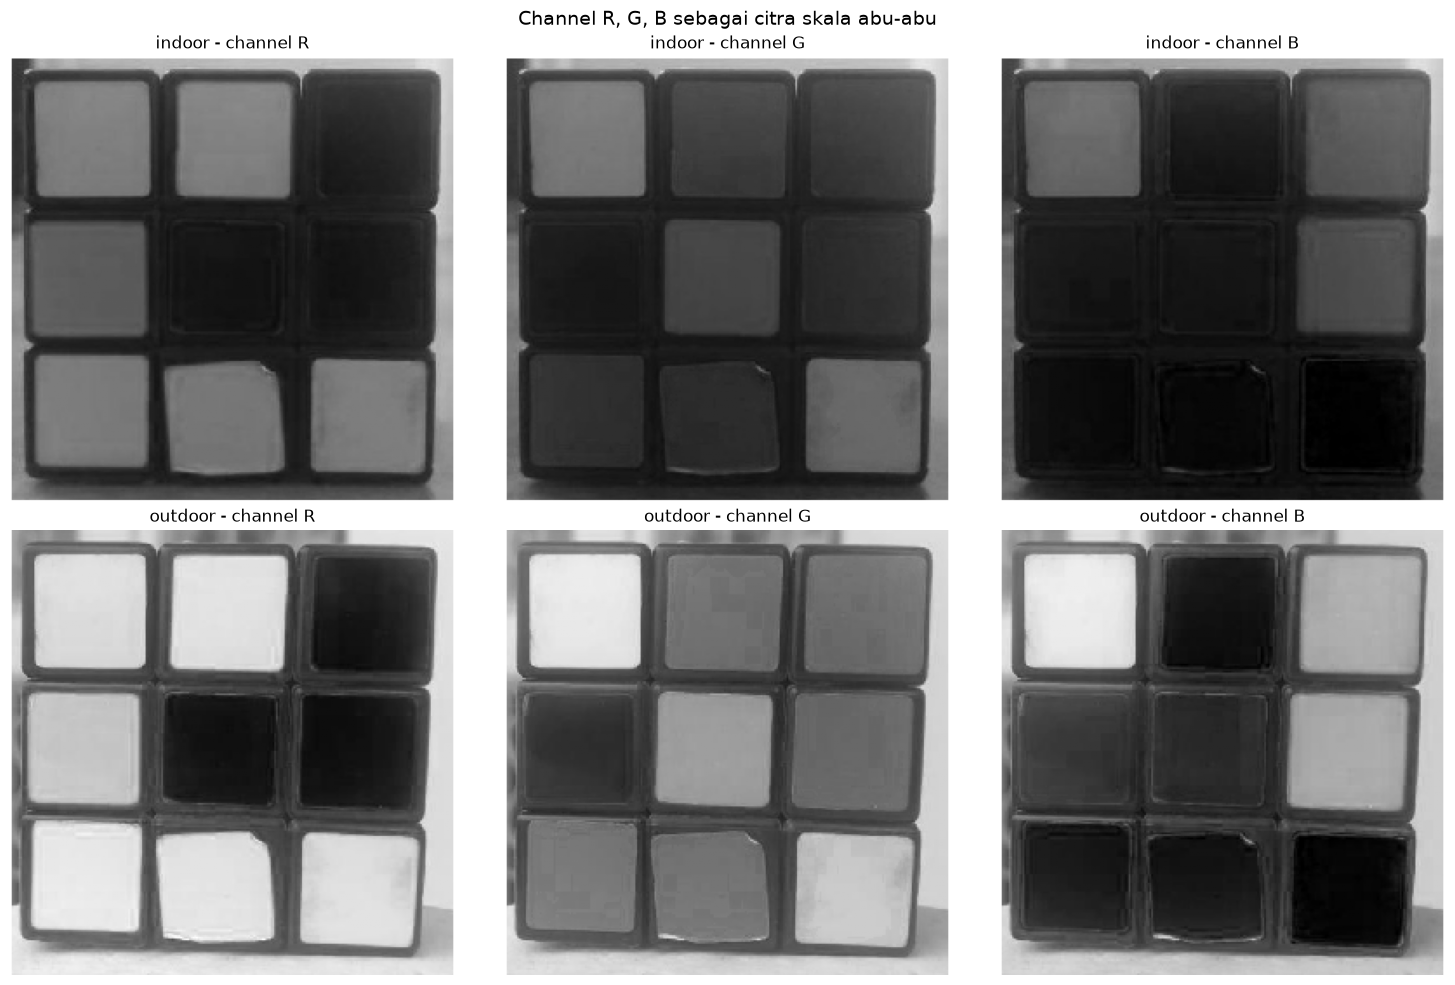

In [3]:
# Plot channel R, G, B masing-masing citra sebagai citra skala abu-abu.
# Skala intensitas dikunci pada vmin=0, vmax=255 agar perbedaan terang-gelap
# antar citra terlihat apa adanya (tidak dinormalisasi otomatis oleh Matplotlib).
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (img, nama) in enumerate([(indoor, 'indoor'), (outdoor, 'outdoor')]):
    for col, ch in enumerate(['R', 'G', 'B']):
        ax = axes[row, col]
        ax.imshow(img[:, :, col], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{nama} - channel {ch}')
        ax.axis('off')

plt.suptitle('Channel R, G, B sebagai citra skala abu-abu', fontsize=14)
plt.tight_layout()
plt.show()

## b. Konversi ke ruang warna LAB dan plot ketiga channel-nya

Ruang warna LAB memisahkan informasi citra menjadi:

- **L** (*lightness*): terang/gelap piksel, murni informasi luminansi.
- **a**: sumbu kromatik hijau ↔ merah.
- **b**: sumbu kromatik biru ↔ kuning.

Catatan: pada OpenCV untuk citra 8-bit, nilai disimpan terskala menjadi
`L ∈ [0, 255]` (aslinya 0 sampai 100) serta `a, b ∈ [0, 255]` dengan titik netral di 128
(aslinya −128 sampai +127).

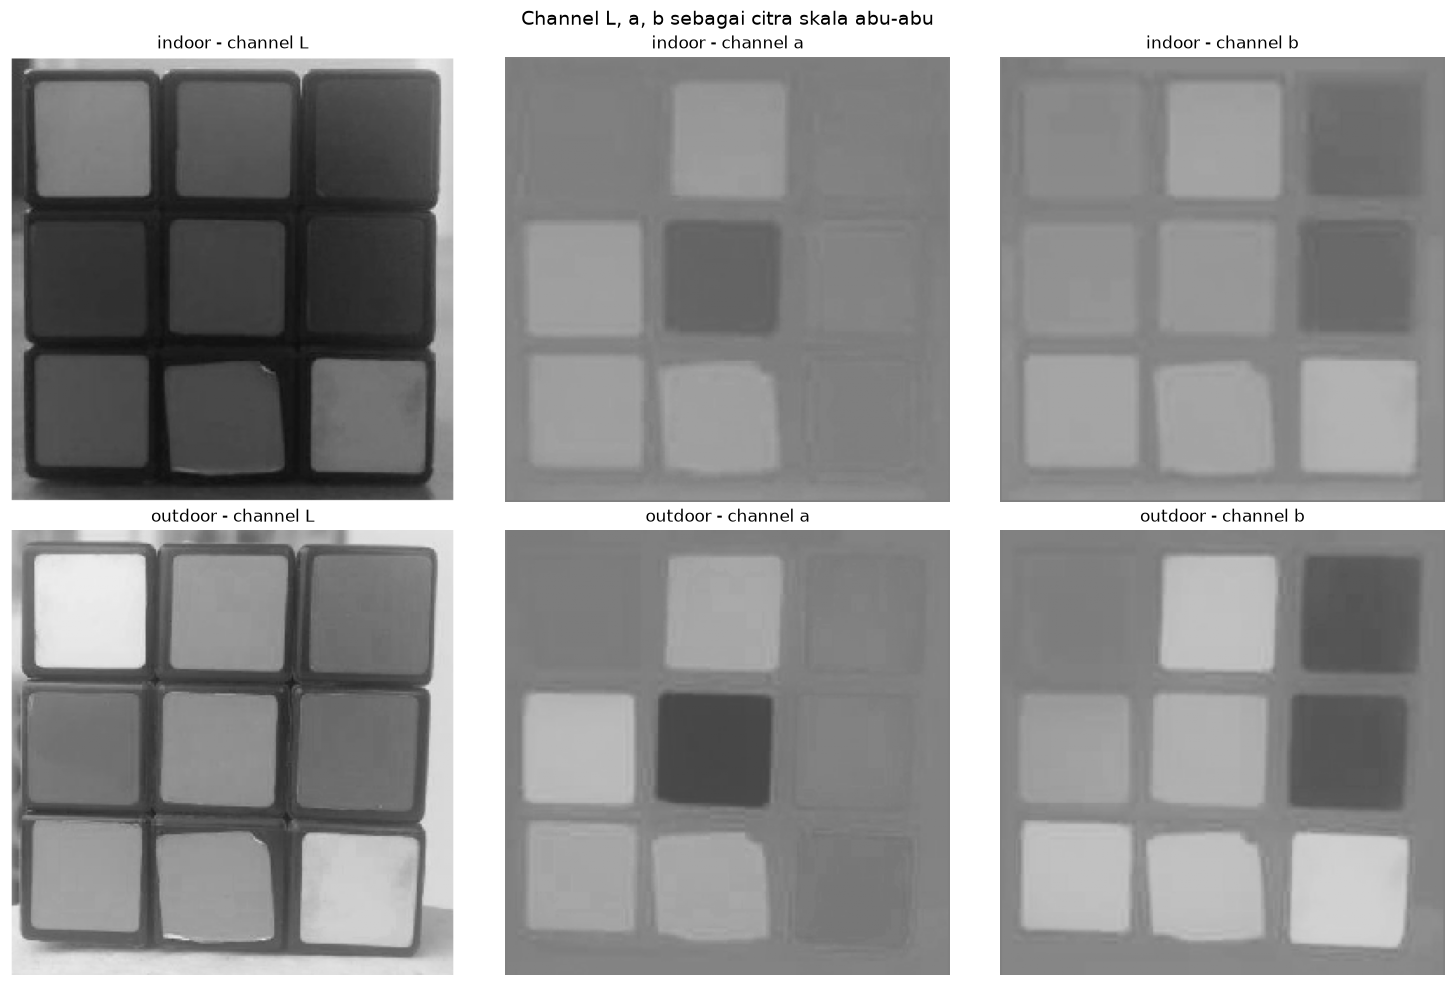

In [4]:
# Konversi ke LAB (dari BGR, sesuai citra hasil cv2.imread)
indoor_lab = cv2.cvtColor(indoor_bgr, cv2.COLOR_BGR2LAB)
outdoor_lab = cv2.cvtColor(outdoor_bgr, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (lab, nama) in enumerate([(indoor_lab, 'indoor'), (outdoor_lab, 'outdoor')]):
    for col, ch in enumerate(['L', 'a', 'b']):
        ax = axes[row, col]
        ax.imshow(lab[:, :, col], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{nama} - channel {ch}')
        ax.axis('off')

plt.suptitle('Channel L, a, b sebagai citra skala abu-abu', fontsize=14)
plt.tight_layout()
plt.show()

## c. Bagaimana kita tahu perubahan pencahayaan terpisah lebih baik di LAB?

Klaim ini tidak cukup dilihat secara visual saja, jadi kita ukur: hitung rata-rata (mean)
tiap channel pada kedua citra, lalu lihat **seberapa besar channel itu bergeser** ketika
iluminasi berubah dari indoor ke outdoor. Kalau ruang warna berhasil memisahkan
pencahayaan, pergeseran seharusnya **menumpuk di satu channel saja** (channel luminansi)
dan mendekati nol di channel lainnya.

In [5]:
def statistik_channel(img_a, img_b, nama_channel):
    baris = []
    for k, ch in enumerate(nama_channel):
        a = img_a[:, :, k].astype(np.float64)
        b = img_b[:, :, k].astype(np.float64)
        baris.append((ch, a.mean(), b.mean(), b.mean() - a.mean()))
    return baris

rgb_stats = statistik_channel(indoor, outdoor, ['R', 'G', 'B'])
lab_stats = statistik_channel(indoor_lab, outdoor_lab, ['L', 'a', 'b'])

print('Ruang warna RGB')
print(f"{'ch':<4}{'mean indoor':>13}{'mean outdoor':>14}{'selisih':>10}")
for ch, mi, mo, d in rgb_stats:
    print(f'{ch:<4}{mi:>13.1f}{mo:>14.1f}{d:>+10.1f}')

print()
print('Ruang warna LAB')
print(f"{'ch':<4}{'mean indoor':>13}{'mean outdoor':>14}{'selisih':>10}")
for ch, mi, mo, d in lab_stats:
    print(f'{ch:<4}{mi:>13.1f}{mo:>14.1f}{d:>+10.1f}')

Ruang warna RGB
ch    mean indoor  mean outdoor   selisih
R            83.5         141.5     +57.9
G            68.0         128.4     +60.3
B            51.2          98.5     +47.3

Ruang warna LAB
ch    mean indoor  mean outdoor   selisih
L            77.4         142.4     +65.0
a           134.0         134.5      +0.4
b           141.1         146.1      +5.0


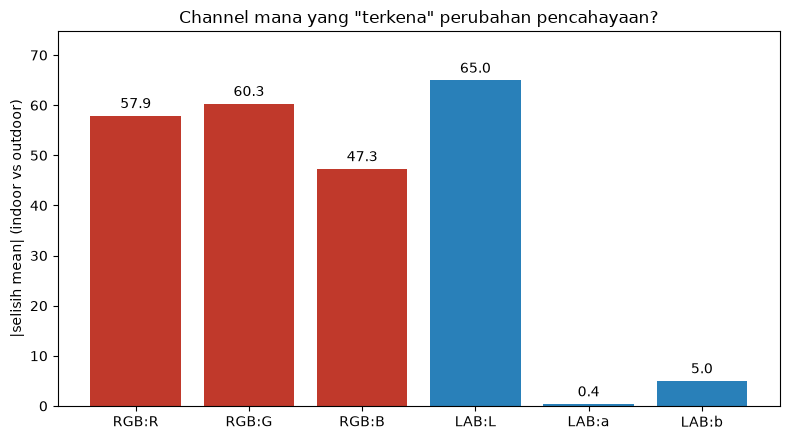

In [6]:
# Visualisasi besarnya pergeseran mean tiap channel akibat perubahan iluminasi
fig, ax = plt.subplots(figsize=(8, 4.5))

label = [f'RGB:{c}' for c, *_ in rgb_stats] + [f'LAB:{c}' for c, *_ in lab_stats]
nilai = [abs(d) for *_, d in rgb_stats] + [abs(d) for *_, d in lab_stats]
warna = ['#c0392b'] * 3 + ['#2980b9'] * 3

bars = ax.bar(label, nilai, color=warna)
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_ylabel('|selisih mean| (indoor vs outdoor)')
ax.set_title('Channel mana yang "terkena" perubahan pencahayaan?')
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

### Penjelasan

**Bukti dari angka di atas.** Di RGB, ketiga channel ikut bergeser dalam jumlah yang
besar dan hampir sama (R ≈ +58, G ≈ +60, B ≈ +47). Artinya informasi "seberapa terang
cahayanya" tercampur ke dalam ketiga channel sekaligus, tidak ada satu pun channel R,
G, atau B yang bisa dipakai sebagai "warna murni" yang bebas pencahayaan. Ini juga
terlihat pada plot bagian (a): ketiga channel citra outdoor sama-sama tampak jauh lebih
terang daripada versi indoor-nya.

Di LAB, pergeserannya **terkumpul di channel L** (≈ +65), sedangkan channel a hanya
bergeser ≈ +0.4 dan channel b ≈ +5.0, praktis tidak berubah dibandingkan skala
0 sampai 255 nya. Pada plot bagian (b), channel a dan b kedua citra terlihat sangat mirip
(pola objek yang sama, tingkat abu-abu yang sama), yang berubah drastis hanya
channel L.

**Mengapa demikian.** RGB adalah ruang warna *device-oriented*: tiap channel adalah
respons sensor terhadap intensitas cahaya pada pita panjang gelombang tertentu. Jika
intensitas iluminasi naik, seluruh respons ikut naik kira-kira secara multiplikatif
(model sederhana: `piksel ≈ iluminasi × reflektansi permukaan`), sehingga terang dan
warna tidak terpisahkan.

LAB dirancang untuk memisahkan keduanya secara eksplisit: **L** hanya membawa
luminansi, sedangkan **a** dan **b** membawa kromatisitas (posisi warna pada sumbu
hijau ke merah dan biru ke kuning) yang relatif tidak bergantung pada seberapa kuat cahaya
yang menyinari objek. Perubahan iluminasi karenanya sebagian besar hanya menggeser L,
sementara a dan b tetap.

**Konsekuensi praktis.** Untuk tugas seperti segmentasi berbasis warna, *color
matching*, atau deteksi objek yang harus tahan terhadap perbedaan pencahayaan, jauh
lebih andal memakai channel a dan b (atau membuang/menormalisasi L) daripada
menggunakan RGB mentah. Ambang warna yang dikalibrasi pada citra indoor akan langsung
gagal pada citra outdoor jika dikerjakan di RGB, tetapi tetap berlaku di bidang a dan b.

**Catatan.** Pemisahan ini baik, tetapi tidak sempurna. Channel b masih bergeser
≈ +5.0 karena perubahan pencahayaan di sini bukan hanya soal intensitas, melainkan
juga **suhu warna** sumber cahaya (lampu dalam ruangan cenderung kekuningan, cahaya
siang lebih kebiruan). Perubahan warna sumber cahaya seperti ini memang menggeser
kromatisitas, dan untuk mengompensasinya diperlukan langkah *white balancing* /
*color constancy*, bukan sekadar konversi ruang warna.